# 14. When Explanations Conflict with Causal Reasoning

The previous notebooks built a practical toolkit for interpreting models: coefficients, tree paths, partial dependence, ALE, permutation importance, SHAP-style reasoning, LIME-style local surrogates, counterfactual recourse, ranking explanations, and stability checks.

This notebook adds a necessary discipline: **an explanation of a prediction still needs causal discipline before it becomes an explanation of the world**.

That distinction matters in decision systems. A model may correctly explain why it predicted that an account is likely to churn, but the explanation may still be wrong as a guide to intervention. A variable can be predictive because it is a symptom, a proxy, a mediator, a collider, a selection artifact, or a consequence of the action. Causal reasoning is the audit layer that decides whether an explanation can support a decision.

## Mathematical Core

A predictive explanation decomposes model behavior. For feature $X_j$ and model $f$, an attribution can be written abstractly as

$$
E_j(x; f) \approx \text{contribution of}\; X_j \; \mathrm{to}\; f(x).
$$

A causal estimand asks a different question:

$$
\tau_j = \mathbb{E}[Y(x_j+\Delta, X_{-j}) - Y(x_j, X_{-j})]
$$

under an intervention that changes $X_j$. These quantities can disagree because $E_j$ follows the fitted prediction function and the data distribution, while $\tau_j$ depends on an intervention and assumptions about the data-generating process. The lecture should keep these two objects separate before comparing them.


## Learning Objectives

By the end of this notebook, you should be able to:

1. Distinguish predictive explanations from causal explanations.
2. Explain why feature importance, SHAP values, coefficients, and local surrogates are not treatment effects.
3. Diagnose three common conflicts: confounding, post-treatment leakage, and selection/collider bias.
4. Use adjustment, inverse propensity weighting, and role-based feature review to reconcile model explanations with causal decision questions.
5. Communicate explanation limits professionally in a high-stakes analytics workflow.

## 1. Two Different Questions

A predictive explanation asks:

$$
\text{Why did the fitted model } \widehat f(x) \text{ produce this prediction?}
$$

A causal explanation asks:

$$
\text{What would happen to the outcome if we intervened on an action?}
$$

For a binary action or treatment $T$, the average treatment effect is:

$$
\operatorname{ATE} = E[Y(1) - Y(0)].
$$

Equivalently, in intervention notation:

$$
\operatorname{ATE} = E[Y \mid do(T=1)] - E[Y \mid do(T=0)].
$$

These are not the same target. A feature can be important for predicting $Y$ without being a valid lever for changing $Y$.

## 2. Why XAI and Causality Can Disagree

Modern XAI methods often explain a fitted prediction function. They answer questions about the model surface, not necessarily about the data-generating process. Janzing, Minorics, and Bloebaum (2019) make this point directly by framing feature relevance in XAI as a causal problem and warning that observational and interventional distributions should not be mixed casually. Zhao and Hastie (2019) similarly emphasize that black-box model interpretation needs causal language when users want interventional meaning.

The practical rule is simple.

> Use predictive explanations to understand model behavior. Use causal reasoning to decide whether the explanation supports an action.

This notebook uses a synthetic retention decision system to make that contrast visible.

In [1]:
# Section focus: 2. Why XAI and Causality Can Disagree.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

import os
os.environ.setdefault('MPLCONFIGDIR', '/tmp/matplotlib-cache')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display, Markdown
from matplotlib.patches import FancyArrowPatch
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, average_precision_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

RANDOM_SEED = 614
sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.dpi'] = 130
pd.set_option('display.max_colwidth', 120)

def sigmoid(z):
    """Map a linear score to a probability-like value for the notebook simulation.
    
    Parameters
    ----------
    z : object
        Linear predictor or standardized score being transformed by this helper.
    
    Returns
    -------
    object
        Numeric diagnostic, score, or transformed value from the sigmoid calculation.
    """
    return 1 / (1 + np.exp(-z))

In [2]:
def display_table(df, precision=3, max_width='760px'):
    """Display table for the 14. When Explanations Conflict with Causal Reasoning notebook output.
    
    Parameters
    ----------
    df : object
        Input data frame containing the rows used in this notebook example.
    precision : object
        Number of decimal places used when formatting numeric output.
    max_width : object
        Maximum display width used to keep rendered tables readable.
    
    Returns
    -------
    object
        None. The function updates a plot, display object, or notebook state as its side effect.
    """
    styler = df.style.format(precision=precision)
    styler = styler.set_table_styles([
        {'selector': 'th', 'props': [('white-space', 'normal'), ('text-align', 'left'), ('vertical-align', 'top')]},
        {'selector': 'td', 'props': [('white-space', 'normal'), ('text-align', 'left'), ('vertical-align', 'top'), ('line-height', '1.3')]},
        {'selector': 'table', 'props': [('table-layout', 'fixed'), ('width', max_width)]},
    ])
    display(styler)

The explanation result should be compared with the decision story. In Why XAI and Causality Can Disagree, stable features, changing local reasons, and disagreement across explainers tell us how much trust to place in the model narrative. When the explanation is weak, human reviewers have to reconstruct the reasoning themselves.


## 3. Decision Case: Customer Enablement and Renewal

Suppose a customer-success team runs a training and enablement program for accounts at risk of non-renewal. The business question is causal:

> Should we expand the enablement program because it improves renewal probability?

The prediction question is different:

> Which accounts are likely to renew or fail to renew?

The program is not randomized. High-risk accounts are more likely to receive training. That creates a classic confounding-by-indication pattern: the action is targeted at accounts already in trouble.

The simulated data separate a prediction problem from a causal problem. The model can learn which accounts renew, but the business wants to know whether enablement caused renewal to improve. Those are different questions because treatment assignment is targeted. Weak accounts are more likely to receive training, and post-training usage is partly caused by the intervention.

The experiment deliberately includes confounding, mediation, and selection-like review behavior. That lets us show why an explanation of a prediction model can be accurate about the fitted model while still being unsafe as a causal story. The dataset is not trying to make explanation tools fail unfairly; it is creating the conditions under which causal interpretation needs extra discipline.


### Variable Roles

| Variable | Role | Interpretation |
|---|---|---|
| `baseline_health` | Pre-treatment confounder | Healthier accounts are less likely to need training and more likely to renew. |
| `implementation_complexity` | Pre-treatment confounder | Complex accounts are more likely to receive support and less likely to renew. |
| `training` | Treatment/action | Enablement program assigned by the customer-success team. |
| `post_usage` | Post-treatment mediator | Usage after training; partly caused by training and partly predictive of renewal. |
| `competitor_offer`, `billing_friction` | Business risk drivers | Predict renewal and escalation. |
| `selected_for_escalation_review` | Selection/collider flag | Accounts appear in an escalation review when multiple risk channels trigger attention. |
| `renewed` | Outcome | The business outcome the organization wants to improve. |

In [3]:
# Section focus: Variable Roles.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

def make_retention_decision_data(n=8000, seed=RANDOM_SEED):
    """Construct the retention decision data helper used in the 14. When Explanations Conflict with Causal Reasoning workflow.
    
    Parameters
    ----------
    n : object
        Number of observations or simulation units used by the calculation.
    seed : object
        Random seed used to make the simulation reproducible.
    
    Returns
    -------
    object
        Tuple of outputs from this workflow, usually data, fitted objects, or diagnostics used by later cells.
    """
    rng = np.random.default_rng(seed)

    account_size = rng.normal(0, 1, n)
    enterprise = rng.binomial(1, sigmoid(-0.25 + 0.90 * account_size), n)
    regulated = rng.binomial(1, sigmoid(-0.65 + 0.55 * enterprise + 0.25 * account_size), n)

    baseline_health = rng.normal(0, 1, n)
    relationship_depth = rng.normal(0, 1, n)
    implementation_complexity = rng.normal(0, 1, n)

    pre_usage = (
        0.45 * baseline_health
        + 0.25 * relationship_depth
        - 0.30 * implementation_complexity
        + rng.normal(0, 0.75, n)
    )

    propensity = sigmoid(
        -0.55
        - 1.35 * baseline_health
        + 0.90 * implementation_complexity
        + 0.45 * enterprise
        + 0.35 * regulated
    )
    training = rng.binomial(1, propensity)

    post_usage = (
        0.58 * pre_usage
        + 0.75 * training
        + 0.35 * baseline_health
        - 0.22 * implementation_complexity
        + rng.normal(0, 0.55, n)
    )

    competitor_offer = rng.binomial(1, sigmoid(-0.75 - 0.35 * baseline_health + 0.45 * account_size), n)
    billing_friction = rng.binomial(1, sigmoid(-0.95 + 0.75 * implementation_complexity + 0.35 * regulated), n)

    renewal_logit = (
        -0.15
        + 0.45 * training
        + 0.55 * baseline_health
        + 0.42 * relationship_depth
        - 0.70 * implementation_complexity
        + 0.20 * pre_usage
        + 1.40 * post_usage
        + 0.22 * enterprise
        - 0.70 * competitor_offer
        - 0.42 * billing_friction
    )
    renewal_probability = sigmoid(renewal_logit)
    renewed = rng.binomial(1, renewal_probability)

    selected_for_escalation_review = rng.binomial(
        1,
        sigmoid(
            -1.10
            + 0.90 * implementation_complexity
            + 0.80 * competitor_offer
            + 0.75 * billing_friction
            + 0.95 * (1 - renewed)
        ),
    )

    post_usage_if_trained = 0.58 * pre_usage + 0.75 + 0.35 * baseline_health - 0.22 * implementation_complexity
    post_usage_if_not_trained = 0.58 * pre_usage + 0.35 * baseline_health - 0.22 * implementation_complexity

    logit_if_trained = (
        -0.15
        + 0.45
        + 0.55 * baseline_health
        + 0.42 * relationship_depth
        - 0.70 * implementation_complexity
        + 0.20 * pre_usage
        + 1.40 * post_usage_if_trained
        + 0.22 * enterprise
        - 0.70 * competitor_offer
        - 0.42 * billing_friction
    )
    logit_if_not_trained = (
        -0.15
        + 0.55 * baseline_health
        + 0.42 * relationship_depth
        - 0.70 * implementation_complexity
        + 0.20 * pre_usage
        + 1.40 * post_usage_if_not_trained
        + 0.22 * enterprise
        - 0.70 * competitor_offer
        - 0.42 * billing_friction
    )

    true_ate = np.mean(sigmoid(logit_if_trained) - sigmoid(logit_if_not_trained))

    df = pd.DataFrame({
        'account_size': account_size,
        'enterprise': enterprise,
        'regulated': regulated,
        'baseline_health': baseline_health,
        'relationship_depth': relationship_depth,
        'implementation_complexity': implementation_complexity,
        'pre_usage': pre_usage,
        'training': training,
        'post_usage': post_usage,
        'competitor_offer': competitor_offer,
        'billing_friction': billing_friction,
        'selected_for_escalation_review': selected_for_escalation_review,
        'renewed': renewed,
        'propensity_true': propensity,
        'renewal_probability_true': renewal_probability,
    })

    return df, true_ate

retention, true_ate = make_retention_decision_data()
retention.head()

,account_size,enterprise,regulated,baseline_health,relationship_depth,implementation_complexity,pre_usage,training,post_usage,competitor_offer,billing_friction,selected_for_escalation_review,renewed,propensity_true,renewal_probability_true
0,-1.425622,0,0,-0.605601,1.042988,0.980885,-0.996668,0,-0.376156,1,1,1,0,0.759576,0.070594
1,-0.731060,0,0,-0.174917,0.128925,0.542054,0.095666,1,0.606658,0,1,1,0,0.543387,0.581020
2,-0.642607,0,0,0.685893,-0.140596,0.180135,0.929028,0,0.494856,0,1,1,0,0.211846,0.622624
3,0.045735,1,1,0.784604,1.009673,0.045202,0.037902,0,0.937884,0,0,0,1,0.316796,0.901550
4,0.024838,0,0,-0.382966,-0.640103,0.456999,-0.967919,0,-0.548195,0,1,1,0,0.593464,0.088634


Read Variable Roles as a stress test for the explanation. Stable reasons strengthen the story; shifting local reasons should stay in the caveats.


In [4]:
summary = pd.DataFrame({
    'quantity': [
        'Accounts',
        'Training rate',
        'Renewal rate',
        'Escalation-review selection rate',
        'True ATE of training on renewal probability',
    ],
    'value': [
        len(retention),
        retention['training'].mean(),
        retention['renewed'].mean(),
        retention['selected_for_escalation_review'].mean(),
        true_ate,
    ],
})

display_table(summary, precision=3, max_width='620px')

,quantity,value
0,Accounts,8000.000
1,Training rate,0.471
2,Renewal rate,0.536
3,Escalation-review selection rate,0.468
4,True ATE of training on renewal probability,0.202


The true average treatment effect is positive in this simulation. Training increases renewal probability through a direct channel and through post-training usage. But because training is assigned to weaker accounts, the raw treated-versus-untreated comparison will be misleading.

In Variable Roles, the explanation should help a reviewer understand what is stable, what is fragile, and what still needs checking. When the story changes under reasonable settings, the report should say so plainly.


## 4. A Causal Map Before Any Explanation

Before reading feature importances, draw the causal story. The graph below is schematic, not an estimate. It forces us to label which variables occur before the action, which are caused by the action, and which arise from selection into a review process.

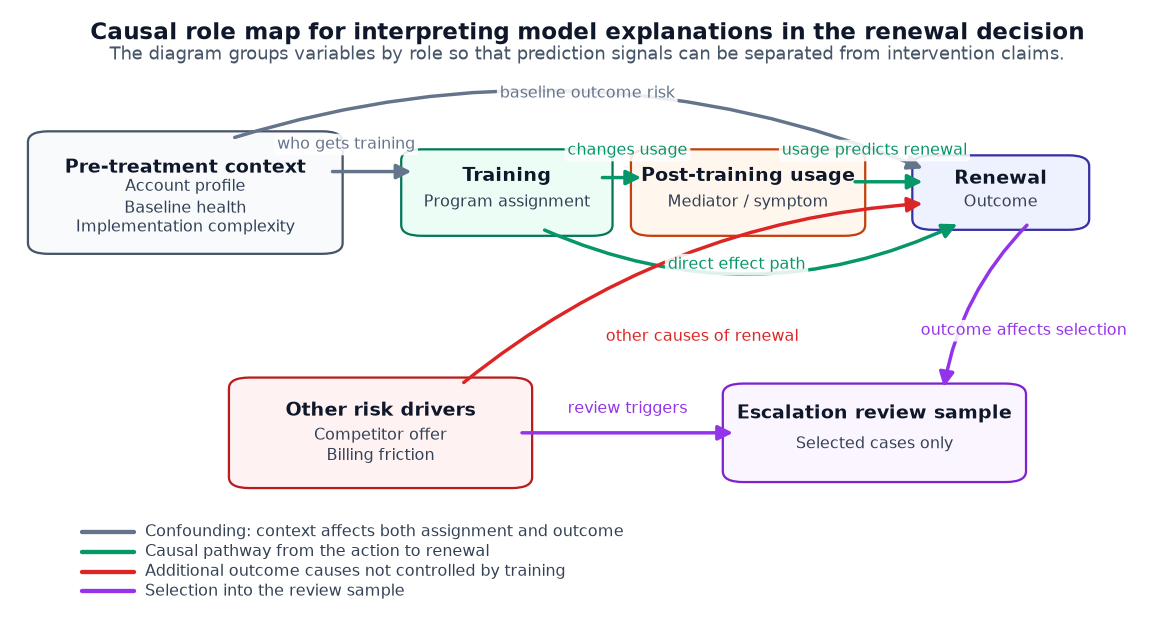

In [5]:
# Section focus: 4. A Causal Map Before Any Explanation.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

def draw_causal_map():
    """Carry out the draw causal map step used in the 14. When Explanations Conflict with Causal Reasoning workflow.
    
    Parameters
    ----------
    None
        This helper uses values defined in the surrounding notebook cell.
    
    Returns
    -------
    object
        Tuple of outputs from this workflow, usually data, fitted objects, or diagnostics used by later cells.
    """
    from matplotlib.patches import FancyBboxPatch, FancyArrowPatch

    fig, ax = plt.subplots(figsize=(11.4, 6.0))
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.axis('off')

    boxes = {}

    def add_box(key, center, width, height, title, lines, face='#ffffff', edge='#334155'):
        """Carry out the add box step used in the 14. When Explanations Conflict with Causal Reasoning workflow.
        
        Parameters
        ----------
        key : object
            The key setting that controls the add box calculation in this notebook.
        center : object
            The center setting that controls the add box calculation in this notebook.
        width : object
            Display setting used to make the plot or table readable in the rendered notebook.
        height : object
            The height setting that controls the add box calculation in this notebook.
        title : object
            Title used to label the displayed result.
        lines : object
            The lines setting that controls the add box calculation in this notebook.
        face : object
            Face color used to encode a node or region in a graph or plot.
        edge : object
            Graph edge being drawn, classified, or checked for consistency.
        
        Returns
        -------
        object
            None. The function updates a plot, display object, or notebook state as its side effect.
        """
        x, y = center
        patch = FancyBboxPatch(
            (x - width / 2, y - height / 2),
            width,
            height,
            boxstyle='round,pad=0.012,rounding_size=0.018',
            linewidth=1.25,
            edgecolor=edge,
            facecolor=face,
            zorder=2,
        )
        ax.add_patch(patch)
        boxes[key] = {'x': x, 'y': y, 'w': width, 'h': height}
        ax.text(x, y + height * 0.23, title, ha='center', va='center', fontsize=10.5, weight='bold', color='#0f172a', zorder=5)
        ax.text(x, y - height * 0.13, '\n'.join(lines), ha='center', va='center', fontsize=9.0, color='#334155', linespacing=1.25, zorder=5)

    def anchor(key, side, offset=0.0):
        """Carry out the anchor step used in the 14. When Explanations Conflict with Causal Reasoning workflow.
        
        Parameters
        ----------
        key : object
            The key setting that controls the anchor calculation in this notebook.
        side : object
            The side setting that controls the anchor calculation in this notebook.
        offset : object
            The offset setting that controls the anchor calculation in this notebook.
        
        Returns
        -------
        object
            Tuple of outputs from this workflow, usually data, fitted objects, or diagnostics used by later cells.
        """
        box = boxes[key]
        x, y, w, h = box['x'], box['y'], box['w'], box['h']
        if side == 'left':
            return (x - w / 2, y + offset)
        if side == 'right':
            return (x + w / 2, y + offset)
        if side == 'top':
            return (x + offset, y + h / 2)
        if side == 'bottom':
            return (x + offset, y - h / 2)
        raise ValueError(side)

    def arrow(start, end, color, rad=0.0, lw=1.9, linestyle='-', label=None, label_xy=None):
        """Carry out the arrow step used in the 14. When Explanations Conflict with Causal Reasoning workflow.
        
        Parameters
        ----------
        start : object
            Starting index, time, or location for the simulated event window.
        end : object
            Ending index, time, or location for the simulated event window.
        color : object
            Display setting used to make the plot or table readable in the rendered notebook.
        rad : object
            Curvature setting used to route a graph edge around other visual elements.
        lw : object
            The lw setting that controls the arrow calculation in this notebook.
        linestyle : object
            The linestyle setting that controls the arrow calculation in this notebook.
        label : object
            Human-readable label used to name a model, scenario, metric, or plotted series.
        label_xy : object
            Display setting used to make the plot or table readable in the rendered notebook.
        
        Returns
        -------
        object
            None. The function updates a plot, display object, or notebook state as its side effect.
        """
        patch = FancyArrowPatch(
            start,
            end,
            connectionstyle=f'arc3,rad={rad}',
            arrowstyle='-|>',
            mutation_scale=17,
            linewidth=lw,
            linestyle=linestyle,
            color=color,
            shrinkA=2,
            shrinkB=2,
            zorder=4,
        )
        ax.add_patch(patch)
        if label and label_xy:
            ax.text(
                label_xy[0], label_xy[1], label,
                ha='center', va='center', fontsize=8.8, color=color,
                bbox=dict(boxstyle='round,pad=0.18', facecolor='white', edgecolor='none', alpha=0.88),
                zorder=6,
            )

    add_box(
        'context', (0.15, 0.70), 0.25, 0.18,
        'Pre-treatment context',
        ['Account profile', 'Baseline health', 'Implementation complexity'],
        face='#f8fafc', edge='#475569',
    )
    add_box(
        'training', (0.43, 0.70), 0.16, 0.12,
        'Training', ['Program assignment'],
        face='#ecfdf5', edge='#047857',
    )
    add_box(
        'usage', (0.64, 0.70), 0.18, 0.12,
        'Post-training usage', ['Mediator / symptom'],
        face='#fff7ed', edge='#c2410c',
    )
    add_box(
        'renewal', (0.86, 0.70), 0.13, 0.10,
        'Renewal', ['Outcome'],
        face='#eef2ff', edge='#3730a3',
    )
    add_box(
        'risks', (0.32, 0.30), 0.24, 0.16,
        'Other risk drivers',
        ['Competitor offer', 'Billing friction'],
        face='#fef2f2', edge='#b91c1c',
    )
    add_box(
        'review', (0.75, 0.30), 0.24, 0.14,
        'Escalation review sample',
        ['Selected cases only'],
        face='#faf5ff', edge='#7e22ce',
    )

    gray = '#64748b'
    green = '#059669'
    red = '#dc2626'
    purple = '#9333ea'

    arrow(anchor('context', 'right', 0.035), anchor('training', 'left', 0.035), gray, label='who gets training', label_xy=(0.29, 0.78))
    arrow(anchor('context', 'top', 0.04), anchor('renewal', 'left', 0.038), gray, rad=-0.18, label='baseline outcome risk', label_xy=(0.50, 0.865))

    arrow(anchor('training', 'right', 0.025), anchor('usage', 'left', 0.025), green, label='changes usage', label_xy=(0.535, 0.77))
    arrow(anchor('usage', 'right', 0.018), anchor('renewal', 'left', 0.018), green, label='usage predicts renewal', label_xy=(0.75, 0.77))
    arrow(anchor('training', 'bottom', 0.03), anchor('renewal', 'bottom', -0.035), green, rad=0.23, label='direct effect path', label_xy=(0.63, 0.58))

    arrow(anchor('risks', 'top', 0.07), anchor('renewal', 'left', -0.018), red, rad=-0.16, label='other causes of renewal', label_xy=(0.60, 0.46))
    arrow(anchor('risks', 'right', 0.00), anchor('review', 'left', 0.00), purple, label='review triggers', label_xy=(0.535, 0.34))
    arrow(anchor('renewal', 'bottom', 0.025), anchor('review', 'top', 0.06), purple, rad=0.16, label='outcome affects selection', label_xy=(0.88, 0.47))

    legend_items = [
        ('#64748b', 'Confounding: context affects both assignment and outcome'),
        ('#059669', 'Causal pathway from the action to renewal'),
        ('#dc2626', 'Additional outcome causes not controlled by training'),
        ('#9333ea', 'Selection into the review sample'),
    ]
    for i, (color, text) in enumerate(legend_items):
        y = 0.135 - i * 0.033
        ax.plot([0.06, 0.105], [y, y], color=color, linewidth=2.4, solid_capstyle='round')
        ax.text(0.115, y, text, ha='left', va='center', fontsize=9.1, color='#334155')

    ax.text(
        0.50, 0.985,
        'Causal role map for interpreting model explanations in the renewal decision',
        ha='center', va='top', fontsize=13, weight='bold', color='#0f172a',
    )
    ax.text(
        0.50, 0.945,
        'The diagram groups variables by role so that prediction signals can be separated from intervention claims.',
        ha='center', va='top', fontsize=10.2, color='#475569',
    )
    return fig, ax

draw_causal_map();
plt.show()

Use the explanation as a stress test of the model narrative. In A Causal Map Before Any Explanation, the displayed reasons should make sense with the data-generating story and the operating decision. Conflicting explanation views should lower the confidence of the story presented to stakeholders.


### How to Read the Flowchart

The flowchart is a role map, not a fitted model. It explains why a feature can be useful for prediction and still be unsafe for causal decision-making.

1. **Pre-treatment context affects assignment and renewal.** Account profile, baseline health, and implementation complexity are measured before the training decision. They help determine who receives training, and they also affect renewal. That makes them potential confounders of the training-renewal relationship.

2. **Training has a causal pathway to renewal.** The green arrows represent the intervention story. Training can affect renewal directly, and it can also affect renewal indirectly by improving post-training usage.

3. **Post-training usage is a mediator, not an ordinary control.** Because usage is measured after training and is partly caused by training, it is valuable for forecasting renewal but dangerous if the goal is to estimate the total effect of training. Controlling for it can block part of the effect we want to measure.

4. **Other business risks still affect renewal.** Competitor offers and billing friction can reduce renewal independently of training. A prediction model should use these signals when available, but they are not evidence that training itself caused the outcome.

5. **The escalation-review sample is selected.** Cases enter review because of risk triggers and outcomes. Explanations computed only on reviewed cases describe a selected sample. They may be useful for audit triage, but they should not be treated as population-level causal evidence without a selection argument.

The practical takeaway is that every explanation should be translated into one of three claims: **model behavior**, **statistical association**, or **causal effect**. Only the last claim justifies an intervention.

Read the numerical results later in the notebook against this map. The naive estimate mixes the green treatment effect with the gray confounding paths. The leakage model becomes attractive because it uses the orange mediator box. The selected-sample diagnostics matter because the purple arrows show that review cases are not a random slice of the population.

## 5. Conflict 1: The Naive Explanation Says Training Is Harmful

The first conflict appears before any complex model. If we simply compare renewal rates, trained accounts appear worse. That is because the training program is targeted toward accounts with lower baseline health and higher implementation complexity.

In [6]:
group_summary = (
    retention
    .groupby('training')
    .agg(
        accounts=('renewed', 'size'),
        renewal_rate=('renewed', 'mean'),
        baseline_health=('baseline_health', 'mean'),
        implementation_complexity=('implementation_complexity', 'mean'),
        post_usage=('post_usage', 'mean'),
    )
    .rename(index={0: 'No training', 1: 'Training'})
)

display_table(group_summary.reset_index(), precision=3, max_width='780px')

,training,accounts,renewal_rate,baseline_health,implementation_complexity,post_usage
0,No training,4232,0.587,0.444,-0.268,0.362
1,Training,3768,0.480,-0.505,0.314,0.332


For Conflict 1: The Naive Explanation Says Training Is Harmful, the right question is whether this explanation can survive baseline, sample, or neighborhood changes.


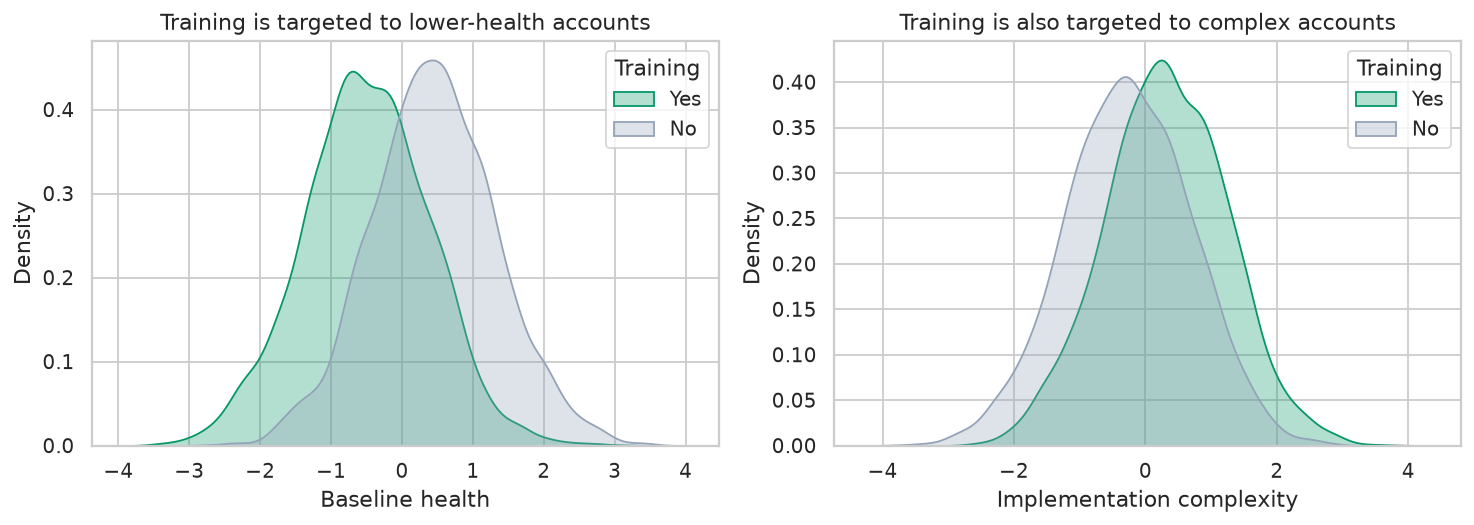

In [7]:
# Section focus: 5. Conflict 1: The Naive Explanation Says Training Is Harmful.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.2))

sns.kdeplot(
    data=retention,
    x='baseline_health',
    hue='training',
    common_norm=False,
    fill=True,
    alpha=0.30,
    ax=axes[0],
    palette={0: '#94a3b8', 1: '#059669'},
)
axes[0].set_title('Training is targeted to lower-health accounts')
axes[0].set_xlabel('Baseline health')
axes[0].legend(title='Training', labels=['Yes', 'No'])

sns.kdeplot(
    data=retention,
    x='implementation_complexity',
    hue='training',
    common_norm=False,
    fill=True,
    alpha=0.30,
    ax=axes[1],
    palette={0: '#94a3b8', 1: '#059669'},
)
axes[1].set_title('Training is also targeted to complex accounts')
axes[1].set_xlabel('Implementation complexity')
axes[1].legend(title='Training', labels=['Yes', 'No'])

plt.tight_layout()
plt.show()

The plot shows selection into treatment. Trained accounts are not comparable to untrained accounts. A predictive explanation may correctly learn that `training` is associated with risk, but that association is not the effect of training.

Read Conflict 1: The Naive Explanation Says Training Is Harmful as a communication test. The explanation should be easy to question without falling apart.


## 6. Causal Adjustment Changes the Answer

If $X$ is a valid pre-treatment adjustment set, the back-door adjustment formula is:

$$
E[Y \mid do(T=t)] = \sum_x E[Y \mid T=t, X=x] P(X=x).
$$

We will compare four estimates:

| Estimate | What it does | Expected behavior |
|---|---|---|
| True simulation ATE | Uses the known synthetic data-generating process | Positive benchmark |
| Naive difference | Compares trained and untrained accounts directly | Biased by targeting high-risk accounts |
| Adjusted outcome model | Holds pre-treatment covariates fixed and changes training | Recovers the sign of the effect |
| Inverse propensity weighting | Reweights accounts using estimated treatment propensities | Also recovers the sign when overlap is adequate |
| Leakage-adjusted model | Holds post-treatment usage fixed while changing training | Understates the total effect by blocking part of the pathway |

In [8]:
# Section focus: 6. Causal Adjustment Changes the Answer.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

pre_treatment_features = [
    'training',
    'account_size',
    'enterprise',
    'regulated',
    'baseline_health',
    'relationship_depth',
    'implementation_complexity',
    'pre_usage',
    'competitor_offer',
    'billing_friction',
]
propensity_features = [feature for feature in pre_treatment_features if feature != 'training']
leakage_features = pre_treatment_features + ['post_usage']

def g_computation_effect(df, features):
    """Carry out the g computation effect step used in the 14. When Explanations Conflict with Causal Reasoning workflow.
    
    Parameters
    ----------
    df : object
        Input data frame containing the rows used in this notebook example.
    features : object
        Feature column names or feature matrix used by the model.
    
    Returns
    -------
    object
        Tuple of outputs from this workflow, usually data, fitted objects, or diagnostics used by later cells.
    """
    model = make_pipeline(StandardScaler(), LogisticRegression(max_iter=2000))
    model.fit(df[features], df['renewed'])

    treated = df[features].copy()
    untreated = df[features].copy()
    treated['training'] = 1
    untreated['training'] = 0

    effect = np.mean(model.predict_proba(treated)[:, 1] - model.predict_proba(untreated)[:, 1])
    return effect, model

naive_effect = (
    retention.loc[retention['training'] == 1, 'renewed'].mean()
    - retention.loc[retention['training'] == 0, 'renewed'].mean()
)
adjusted_effect, adjusted_model = g_computation_effect(retention, pre_treatment_features)
leakage_adjusted_effect, leakage_adjusted_model = g_computation_effect(retention, leakage_features)

propensity_model = make_pipeline(StandardScaler(), LogisticRegression(max_iter=2000))
propensity_model.fit(retention[propensity_features], retention['training'])
estimated_propensity = propensity_model.predict_proba(retention[propensity_features])[:, 1]
estimated_propensity = np.clip(estimated_propensity, 0.03, 0.97)

w_treated = retention['training'] / estimated_propensity
w_untreated = (1 - retention['training']) / (1 - estimated_propensity)
ipw_effect = (
    np.sum(w_treated * retention['renewed']) / np.sum(w_treated)
    - np.sum(w_untreated * retention['renewed']) / np.sum(w_untreated)
)

effect_table = pd.DataFrame({
    'estimate': [
        'True ATE from the simulation',
        'Naive trained - untrained difference',
        'Adjusted g-computation using pre-treatment variables',
        'Inverse propensity weighted difference',
        'Model that adjusts for post-treatment usage',
    ],
    'renewal_probability_difference': [
        true_ate,
        naive_effect,
        adjusted_effect,
        ipw_effect,
        leakage_adjusted_effect,
    ],
    'interpretation': [
        'Benchmark: training helps renewal.',
        'Wrong sign because trained accounts were already weaker.',
        'Closer to the total effect because adjustment uses pre-treatment variables.',
        'Similar conclusion from a design-based reweighting view.',
        'Too small for the total effect because it holds a mediator fixed.',
    ],
})

display_table(effect_table, precision=3, max_width='860px')

,estimate,renewal_probability_difference,interpretation
0,True ATE from the simulation,0.202,Benchmark: training helps renewal.
1,Naive trained - untrained difference,-0.107,Wrong sign because trained accounts were already weaker.
2,Adjusted g-computation using pre-treatment variables,0.190,Closer to the total effect because adjustment uses pre-treatment variables.
3,Inverse propensity weighted difference,0.189,Similar conclusion from a design-based reweighting view.
4,Model that adjusts for post-treatment usage,0.064,Too small for the total effect because it holds a mediator fixed.


Causal Adjustment Changes the Answer should make the model story easier to inspect instead of merely more polished.


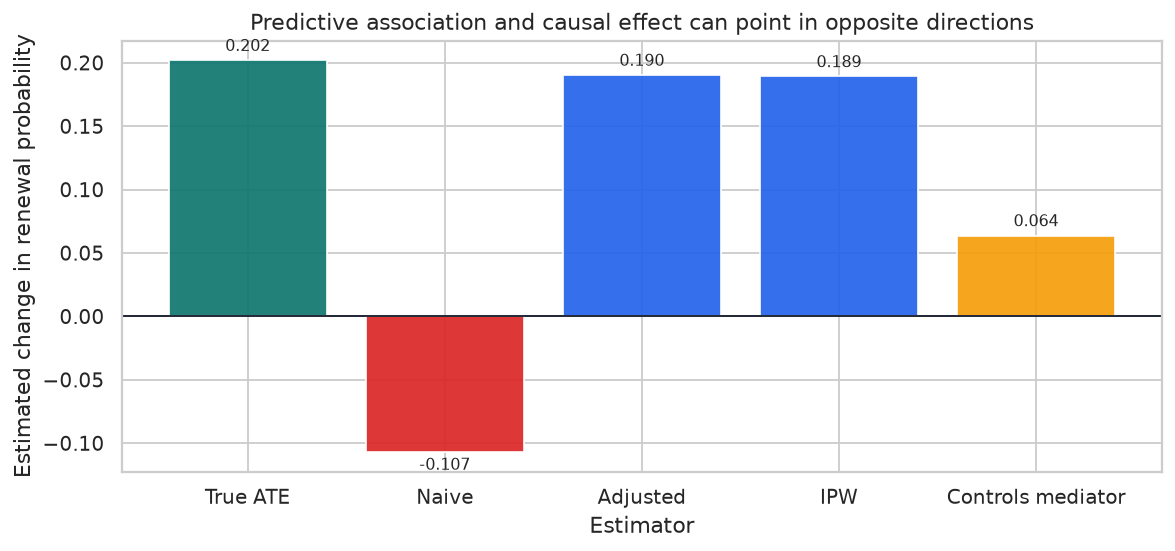

In [9]:
# Section focus: 6. Causal Adjustment Changes the Answer.
# The code below keeps the calculation explicit so each intermediate step can be inspected.

plot_effects = effect_table.copy()
plot_effects['short_name'] = [
    'True ATE',
    'Naive',
    'Adjusted',
    'IPW',
    'Controls mediator',
]

fig, ax = plt.subplots(figsize=(9.2, 4.4))
colors = ['#0f766e', '#dc2626', '#2563eb', '#2563eb', '#f59e0b']
ax.bar(
    plot_effects['short_name'],
    plot_effects['renewal_probability_difference'],
    color=colors,
    alpha=0.92,
)
ax.axhline(0, color='#111827', linewidth=1)
ax.set_title('Predictive association and causal effect can point in opposite directions')
ax.set_xlabel('Estimator')
ax.set_ylabel('Estimated change in renewal probability')
for container in ax.containers:
    ax.bar_label(container, fmt='%.3f', padding=3, fontsize=9)
plt.tight_layout()
plt.show()

The naive comparison has the wrong sign. The pre-treatment adjusted estimators recover a positive effect close to the simulation benchmark. The model that controls for `post_usage` estimates a different quantity because `post_usage` is partly caused by training. It blocks part of the pathway through which training helps.

## 7. Conflict 2: The Best Predictive Model May Use a Bad Causal Feature

Now fit two prediction models:

1. A pre-treatment model that only uses information available before the training decision.
2. A leakage model that also uses `post_usage`, a variable measured after training.

The second model may predict better. It may also produce a polished explanation. But if the decision is whether to expand training, explaining predictions with `post_usage` can be misleading because `post_usage` is downstream of the action.

In [10]:
# Section focus: 7. Conflict 2: The Best Predictive Model May Use a Bad Causal Feature.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

train_df, test_df = train_test_split(
    retention,
    test_size=0.30,
    random_state=RANDOM_SEED,
    stratify=retention['renewed'],
)

predictive_models = {}
for name, features in {
    'Pre-treatment model': pre_treatment_features,
    'Leakage model with post_usage': leakage_features,
}.items():
    model = make_pipeline(StandardScaler(), LogisticRegression(max_iter=2000))
    model.fit(train_df[features], train_df['renewed'])
    proba = model.predict_proba(test_df[features])[:, 1]
    predictive_models[name] = {'model': model, 'features': features, 'proba': proba}

performance_table = pd.DataFrame([
    {
        'model': name,
        'features': len(result['features']),
        'roc_auc': roc_auc_score(test_df['renewed'], result['proba']),
        'average_precision': average_precision_score(test_df['renewed'], result['proba']),
    }
    for name, result in predictive_models.items()
])

display_table(performance_table, precision=3, max_width='680px')

,model,features,roc_auc,average_precision
0,Pre-treatment model,10,0.850,0.865
1,Leakage model with post_usage,11,0.877,0.884


This result is an interpretation diagnostic. For Conflict 2: The Best Predictive Model May Use a Bad Causal Feature, look at whether the explanation is stable, plausible, and useful for stakeholder review. A moving narrative should be treated as diagnostic evidence rather than a settled explanation.


In [11]:
# Section focus: 7. Conflict 2: The Best Predictive Model May Use a Bad Causal Feature.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

importance_frames = []
for name, result in predictive_models.items():
    importance = permutation_importance(
        result['model'],
        test_df[result['features']],
        test_df['renewed'],
        n_repeats=8,
        random_state=RANDOM_SEED,
        scoring='roc_auc',
    )
    frame = pd.DataFrame({
        'model': name,
        'feature': result['features'],
        'importance': importance.importances_mean,
        'importance_sd': importance.importances_std,
    })
    importance_frames.append(frame)

importance_table = pd.concat(importance_frames, ignore_index=True)
importance_top = (
    importance_table
    .sort_values(['model', 'importance'], ascending=[True, False])
    .groupby('model')
    .head(7)
)

display_table(importance_top, precision=4, max_width='760px')

,model,feature,importance,importance_sd
20,Leakage model with post_usage,post_usage,0.1471,0.0070
16,Leakage model with post_usage,implementation_complexity,0.0522,0.0024
14,Leakage model with post_usage,baseline_health,0.0286,0.0033
15,Leakage model with post_usage,relationship_depth,0.0159,0.0006
18,Leakage model with post_usage,competitor_offer,0.0072,0.0017
10,Leakage model with post_usage,training,0.0048,0.0009
19,Leakage model with post_usage,billing_friction,0.0029,0.0005
4,Pre-treatment model,baseline_health,0.0957,0.0058
6,Pre-treatment model,implementation_complexity,0.0954,0.0041
7,Pre-treatment model,pre_usage,0.0827,0.0068


The explanation result should be compared with the decision story. In Conflict 2: The Best Predictive Model May Use a Bad Causal Feature, stable features, changing local reasons, and disagreement across explainers tell us how much trust to place in the model narrative. A good explanation makes the recommendation easier to challenge, revise, or defend.


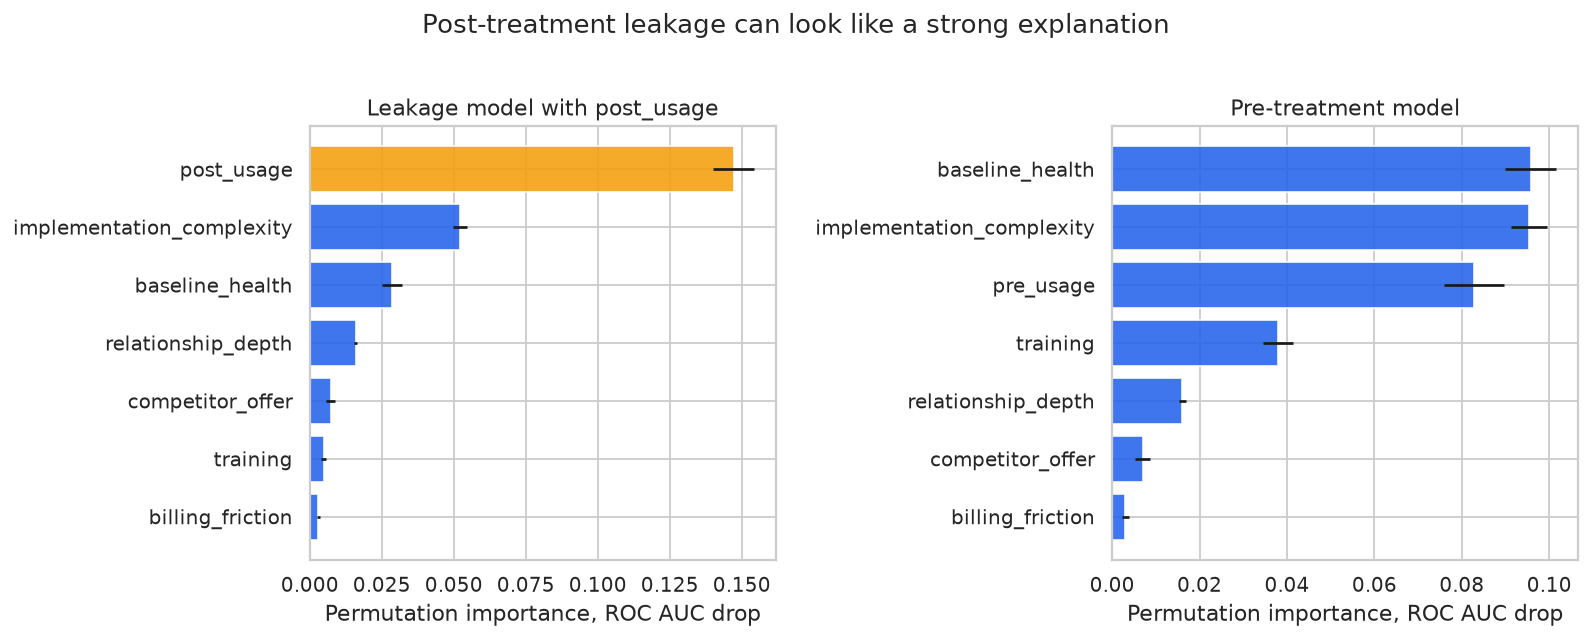

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12.4, 4.8), sharex=False)

for ax, (name, group) in zip(axes, importance_top.groupby('model')):
    ordered = group.sort_values('importance')
    colors = ['#f59e0b' if feature == 'post_usage' else '#2563eb' for feature in ordered['feature']]
    ax.barh(ordered['feature'], ordered['importance'], xerr=ordered['importance_sd'], color=colors, alpha=0.88)
    ax.set_title(name)
    ax.set_xlabel('Permutation importance, ROC AUC drop')
    ax.set_ylabel('')

fig.suptitle('Post-treatment leakage can look like a strong explanation', y=1.02)
plt.tight_layout()
plt.show()

The leakage model improves predictive accuracy and often makes `post_usage` a top explanation. The business recommendation should not become "increase post-usage directly" or "condition on post-usage when evaluating training." The model found a powerful downstream signal.

This is the central conflict: **the best prediction features are not always valid decision features**.

## 8. Prediction Explanation Versus Causal Interpretation

A predictive explanation can be true and still be operationally unsafe. The table below translates common XAI statements into causal-review questions.

| Predictive explanation says | Causal review asks | Decision implication |
|---|---|---|
| `training` is associated with lower renewal. | Who receives training? Was training targeted to high-risk accounts? | Do not infer harm from the raw association. |
| `post_usage` is highly important. | Is usage measured after the intervention? Is it a mediator? | Do not adjust for it when estimating the total effect of training. |
| `baseline_health` is important. | Is it pre-treatment and sufficient for adjustment with other covariates? | Useful for adjustment and targeting, not an intervention itself. |
| `selected_for_escalation_review` identifies high-risk cases. | What process selects accounts into this sample? | Avoid estimating causal effects only inside the selected sample without a selection story. |
| A local explanation suggests changing a feature. | Is that feature actionable, manipulable, and ethically acceptable? | Convert recourse into valid actions, not arbitrary feature edits. |

## 9. Conflict 3: Conditioning on a Selected Sample Can Create Artifacts

Selection variables can behave like colliders. In this simulation, accounts enter an escalation-review sample when several risk channels trigger attention. Two independent risk channels can become associated after conditioning on review selection.

That matters because many explanation workflows are run only on reviewed, denied, escalated, flagged, or manually audited cases. The explanation then describes a selected slice, not the population decision process.

In [13]:
# Section focus: 9. Conflict 3: Conditioning on a Selected Sample Can Create Artifacts.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

def corr_pair(df, columns):
    """Carry out the corr pair step used in the 14. When Explanations Conflict with Causal Reasoning workflow.
    
    Parameters
    ----------
    df : object
        Input data frame containing the rows used in this notebook example.
    columns : object
        Column names selected for this calculation.
    
    Returns
    -------
    object
        Intermediate result produced by the corr pair calculation and reused by later cells.
    """
    return df[list(columns)].corr().iloc[0, 1]

selection_table = pd.DataFrame({
    'sample': ['All accounts', 'Escalation-review sample only'],
    'n_accounts': [len(retention), int(retention['selected_for_escalation_review'].sum())],
    'corr_competitor_offer_billing_friction': [
        corr_pair(retention, ('competitor_offer', 'billing_friction')),
        corr_pair(retention.loc[retention['selected_for_escalation_review'] == 1], ('competitor_offer', 'billing_friction')),
    ],
    'training_rate': [
        retention['training'].mean(),
        retention.loc[retention['selected_for_escalation_review'] == 1, 'training'].mean(),
    ],
    'renewal_rate': [
        retention['renewed'].mean(),
        retention.loc[retention['selected_for_escalation_review'] == 1, 'renewed'].mean(),
    ],
})

display_table(selection_table, precision=3, max_width='780px')

,sample,n_accounts,corr_competitor_offer_billing_friction,training_rate,renewal_rate
0,All accounts,8000,0.008,0.471,0.536
1,Escalation-review sample only,3743,-0.050,0.541,0.349


In Conflict 3: Conditioning on a Selected Sample Can Create Artifacts, pay attention to whether the explanation changes when the analyst changes plausible settings. Setting sensitivity belongs in the report because it changes the strength of the explanation.


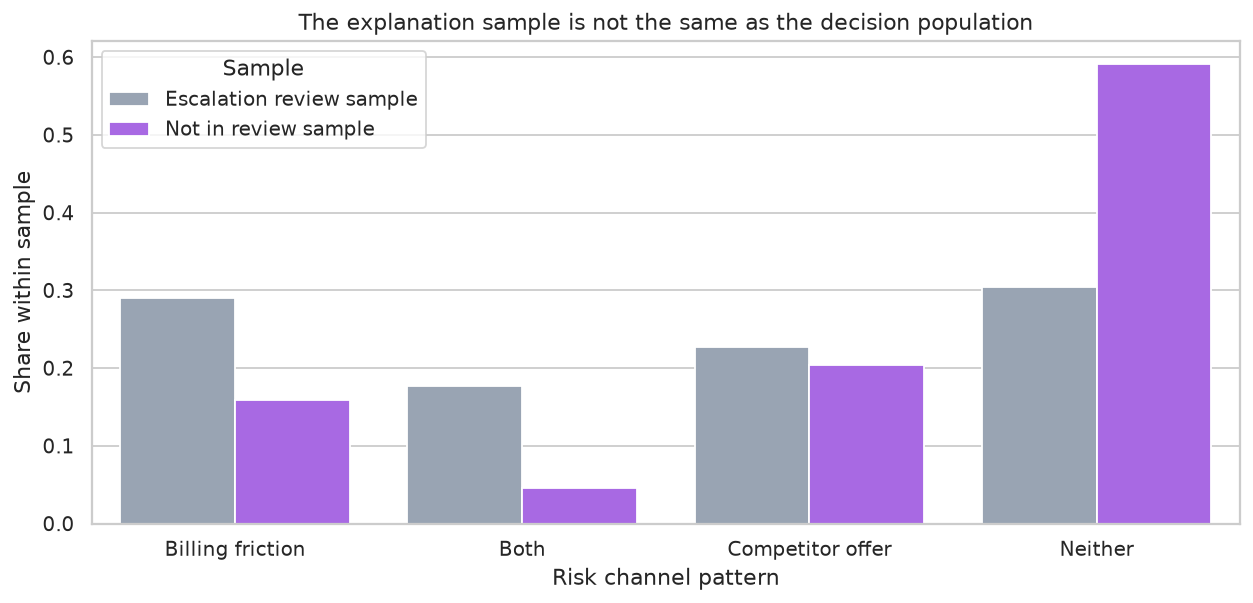

In [14]:
# Section focus: 9. Conflict 3: Conditioning on a Selected Sample Can Create Artifacts.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

plot_selection = retention.copy()
plot_selection['review_sample'] = np.where(
    plot_selection['selected_for_escalation_review'] == 1,
    'Escalation review sample',
    'Not in review sample',
)
plot_selection['risk_channel'] = np.where(
    (plot_selection['competitor_offer'] == 1) & (plot_selection['billing_friction'] == 1), 'Both',
    np.where(plot_selection['competitor_offer'] == 1, 'Competitor offer',
    np.where(plot_selection['billing_friction'] == 1, 'Billing friction', 'Neither')),
)

counts = (
    plot_selection
    .groupby(['review_sample', 'risk_channel'])
    .size()
    .rename('count')
    .reset_index()
)
counts['share'] = counts['count'] / counts.groupby('review_sample')['count'].transform('sum')
share_table = counts.drop(columns='count')
share_table['review_sample'] = share_table['review_sample'].astype(str)
share_table['risk_channel'] = share_table['risk_channel'].astype(str)

fig, ax = plt.subplots(figsize=(9.8, 4.8))
sns.barplot(
    data=share_table,
    x='risk_channel',
    y='share',
    hue='review_sample',
    palette=['#94a3b8', '#a855f7'],
    ax=ax,
)
ax.set_title('The explanation sample is not the same as the decision population')
ax.set_xlabel('Risk channel pattern')
ax.set_ylabel('Share within sample')
ax.legend(title='Sample')
plt.tight_layout()
plt.show()

The selected sample has different risk-channel composition and a different renewal rate. Explanations produced only for selected accounts may be useful for audit triage, but they should not be casually generalized to the full account population.

Use the explanation as a stress test of the model narrative. In Conflict 3: Conditioning on a Selected Sample Can Create Artifacts, the displayed reasons should make sense with the data-generating story and the operating decision. A local explanation should earn trust across methods before it drives action.


## 10. A Small Local Example: Correct Prediction, Unsafe Action Story

Let us choose one trained account with low predicted renewal probability under the leakage model. The model is likely to explain the prediction using post-training usage, baseline health, and implementation complexity. That may be useful for account diagnosis. But the causal action question is not "what if we set post-usage to a higher number?" The question is what feasible action could raise post-usage or renewal.

In [15]:
# Section focus: 10. A Small Local Example: Correct Prediction, Unsafe Action Story.
# The code groups setup, estimation, and diagnostics so the output can be rerun reproducibly.

leakage_model = predictive_models['Leakage model with post_usage']['model']
leakage_feature_names = predictive_models['Leakage model with post_usage']['features']

scaler = leakage_model.named_steps['standardscaler']
logit = leakage_model.named_steps['logisticregression']
coefs = pd.Series(logit.coef_[0], index=leakage_feature_names)
means = pd.Series(scaler.mean_, index=leakage_feature_names)
scales = pd.Series(scaler.scale_, index=leakage_feature_names)

case_pool = test_df.loc[(test_df['training'] == 1) & (test_df['renewed'] == 0)].copy()
case_pool['predicted_renewal'] = leakage_model.predict_proba(case_pool[leakage_feature_names])[:, 1]
focal = case_pool.sort_values('predicted_renewal').iloc[0]

standardized_values = (focal[leakage_feature_names] - means) / scales
logit_contributions = coefs * standardized_values
local_explanation = (
    pd.DataFrame({
        'feature': leakage_feature_names,
        'standardized_value': standardized_values.values,
        'logit_contribution': logit_contributions.values,
        'causal_role': [
            'treatment/action' if f == 'training' else
            'post-treatment mediator' if f == 'post_usage' else
            'pre-treatment or baseline risk factor'
            for f in leakage_feature_names
        ],
    })
    .assign(abs_contribution=lambda d: d['logit_contribution'].abs())
    .sort_values('abs_contribution', ascending=False)
    .head(8)
)

case_summary = pd.DataFrame({
    'quantity': ['Predicted renewal probability', 'Observed renewal', 'Received training', 'Post-training usage'],
    'value': [focal['predicted_renewal'], focal['renewed'], focal['training'], focal['post_usage']],
})

display(Markdown('**Focal account summary**'))
display_table(case_summary, precision=3, max_width='560px')
display(Markdown('**Largest local logit contributions in the leakage model**'))
display_table(local_explanation.drop(columns='abs_contribution'), precision=3, max_width='780px')

**Focal account summary**

,quantity,value
0,Predicted renewal probability,0.000
1,Observed renewal,0.000
2,Received training,1.000
3,Post-training usage,-2.253


**Largest local logit contributions in the leakage model**

,feature,standardized_value,logit_contribution,causal_role
10,post_usage,-2.786,-3.427,post-treatment mediator
4,baseline_health,-2.671,-1.570,pre-treatment or baseline risk factor
6,implementation_complexity,2.028,-1.566,pre-treatment or baseline risk factor
7,pre_usage,-3.631,-0.679,pre-treatment or baseline risk factor
8,competitor_offer,1.434,-0.468,pre-treatment or baseline risk factor
9,billing_friction,1.444,-0.283,pre-treatment or baseline risk factor
0,training,1.063,0.231,treatment/action
5,relationship_depth,-0.427,-0.184,pre-treatment or baseline risk factor


The local explanation is a model explanation. It tells us which variables moved the fitted log-odds for this account. The causal interpretation needs another layer:

- A low `post_usage` contribution may indicate a useful diagnostic symptom.
- It is not a valid adjustment variable for the total effect of training.
- It becomes an intervention only if the organization has a feasible action that changes usage.
- `training` should be evaluated against comparable accounts or through a design such as randomization, quasi-experiment, or careful observational adjustment.

## 11. A Causal Review Checklist for XAI

Before using an explanation to justify an action, classify each feature.

| Feature role | Can it be used for prediction? | Can it be used for causal adjustment? | Can it be recommended as an intervention? |
|---|---:|---:|---:|
| Pre-treatment confounder | Yes | Often yes, if measured before treatment and not a collider | Usually no; it describes context |
| Treatment/action | Yes, with care | It is the intervention whose effect is estimated | Yes, if feasible and governed |
| Mediator | Yes | Not for total-effect adjustment | Maybe, if there is a separate intervention on the mediator |
| Collider/selection flag | Sometimes | Usually no without a selection model | No |
| Outcome proxy measured after action | Yes for forecasting | Dangerous for causal effect estimation | Usually no |
| Protected attribute or sensitive proxy | Sometimes, depending on law and policy | Context-dependent | Typically no as a direct action lever |

## 12. Reconciling the Two Views

A professional workflow does not reject XAI. It places XAI inside a larger decision process.

1. **Start with the action.** Define whether the stakeholder wants to predict, triage, intervene, audit, or allocate resources.
2. **Draw a causal map.** Mark pre-treatment variables, actions, mediators, colliders, and outcomes.
3. **Train the predictive model.** Evaluate accuracy, calibration, stability, and operational utility.
4. **Explain the predictive model.** Use global, local, and stability diagnostics from the previous notebooks.
5. **Audit causal meaning.** Ask whether each explanation is a cause, a proxy, a symptom, a mediator, or a selection artifact.
6. **Report the decision claim.** Separate "the model used this signal" from "changing this lever will change the outcome."

In [16]:
# Section focus: 12. Reconciling the Two Views.
# The code below keeps the calculation explicit so each intermediate step can be inspected.

report_card = pd.DataFrame({
    'finding': [
        'Naive trained accounts renewed less often.',
        'Pre-treatment adjusted estimates are positive.',
        'The leakage model predicts better and highlights post_usage.',
        'The review sample differs from the full population.',
        'A local explanation can identify symptoms but not automatically valid actions.',
    ],
    'causal_reading': [
        'This is confounding by targeted treatment assignment, not evidence that training is harmful.',
        'This supports the hypothesis that training improves renewal in comparable accounts.',
        'post_usage is downstream of training, so it should not be used to estimate the total effect of training.',
        'Explanation claims from selected cases should be labeled as selected-sample evidence.',
        'Action recommendations must be mapped to feasible interventions, not arbitrary feature edits.',
    ],
    'communication_to_stakeholders': [
        'Do not cut training based on the raw comparison.',
        'Consider expansion, but validate with an experiment or stronger observational design.',
        'Use post_usage for monitoring and diagnosis, not as a control in the total-effect estimate.',
        'Separate audit explanations from population-level decision evidence.',
        'Translate explanations into governed operational playbooks.',
    ],
})

display_table(report_card, precision=3, max_width='920px')

,finding,causal_reading,communication_to_stakeholders
0,Naive trained accounts renewed less often.,"This is confounding by targeted treatment assignment, not evidence that training is harmful.",Do not cut training based on the raw comparison.
1,Pre-treatment adjusted estimates are positive.,This supports the hypothesis that training improves renewal in comparable accounts.,"Consider expansion, but validate with an experiment or stronger observational design."
2,The leakage model predicts better and highlights post_usage.,"post_usage is downstream of training, so it should not be used to estimate the total effect of training.","Use post_usage for monitoring and diagnosis, not as a control in the total-effect estimate."
3,The review sample differs from the full population.,Explanation claims from selected cases should be labeled as selected-sample evidence.,Separate audit explanations from population-level decision evidence.
4,A local explanation can identify symptoms but not automatically valid actions.,"Action recommendations must be mapped to feasible interventions, not arbitrary feature edits.",Translate explanations into governed operational playbooks.


For Reconciling the Two Views, the explanation earns trust through stability and reviewability, not through a polished chart alone.


## 13. Key Takeaways

- Predictive explanations describe the fitted model. Causal explanations describe interventions in the world.
- A feature can be predictive, stable, and locally important without being a valid action lever.
- Confounding can make a helpful treatment look harmful in raw comparisons.
- Post-treatment variables can improve prediction while damaging causal interpretation.
- Selected samples can create explanation artifacts that do not generalize to the decision population.
- The safest communication separates three claims: model behavior, statistical association, and causal effect.

## References

Aas, K., Jullum, M., & Loland, A. (2021). Explaining individual predictions when features are dependent: More accurate approximations to Shapley values. *Artificial Intelligence, 298*, 103502. [https://doi.org/10.1016/j.artint.2021.103502](https://doi.org/10.1016/j.artint.2021.103502)

Janzing, D., Minorics, L., & Bloebaum, P. (2019). Feature relevance quantification in explainable AI: A causal problem. *arXiv*. [https://doi.org/10.48550/arxiv.1910.13413](https://doi.org/10.48550/arxiv.1910.13413)

Ribeiro, M. T., Singh, S., & Guestrin, C. (2016). Why should I trust you? Explaining the predictions of any classifier. *Proceedings of the 22nd ACM SIGKDD International Conference on Knowledge Discovery and Data Mining*. [https://doi.org/10.1145/2939672.2939778](https://doi.org/10.1145/2939672.2939778)

Zhao, Q., & Hastie, T. (2021). Causal interpretations of black-box models. *Journal of Business & Economic Statistics, 39*(1), 272-281. [https://doi.org/10.1080/07350015.2019.1624293](https://doi.org/10.1080/07350015.2019.1624293)
